House Prediction Model - by Vinayak Gautam
---------------------------------------------

Data split:
Training set: 70 rows
Testing set: 30 rows
Slopes per feature: [499611.57817658    799.52924997  -5022.46939658 -10025.22267731]
Base price: 3225.700578665361
MAE: 4094.831202328663
MSE: 24709746.473011576
R2 Score: 0.9999777346044176
Predicted Price: 2540871.882767655


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


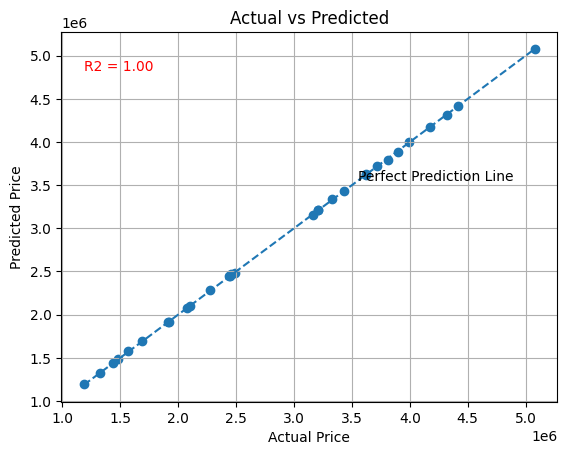

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
n = 100

rooms = np.random.randint(1,7,n)
area_sqft = np.random.randint(500,3000,n)  # fixed
house_age = np.random.randint(0,40,n)
distance_km = np.random.randint(1,50,n)

price = (
    rooms*500000 +
    area_sqft*800 +
    distance_km*(-10000) +
    house_age*(-5000) +
    np.random.randint(-10000, 10000 , n)
)

df = pd.DataFrame({
    'rooms' : rooms,
    'area_sqft' : area_sqft,
    'house_age' : house_age,
    'distance_km' : distance_km,
    'price' : price
})

print("House Prediction Model - by Vinayak Gautam")
print("-"*45)

# FIXED COLUMN NAME
X = df[['rooms','area_sqft','house_age','distance_km']]
Y = df['price']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

print(f"\nData split:")
print(f"Training set: {len(X_train)} rows")
print(f"Testing set: {len(X_test)} rows")

model = LinearRegression()
model.fit(X_train, Y_train)

print("Slopes per feature:", model.coef_)
print("Base price:", model.intercept_)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(Y_test, y_pred))
print("MSE:", mean_squared_error(Y_test, y_pred))
print("R2 Score:", r2_score(Y_test, y_pred))

# Prediction
new_house = np.array([[3,1500,8,12]])
predicted_price = model.predict(new_house)
print("Predicted Price:", predicted_price[0])

# Plot
plt.scatter(Y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

min_val = min(Y_test.min(), y_pred.min())
max_val = max(Y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

r2 = r2_score(Y_test, y_pred)
plt.text(min_val, max_val*0.95, f"R2 = {r2:.2f}", color='red')

plt.text(max_val*0.7, max_val*0.7, "Perfect Prediction Line")

plt.grid(True)
plt.show()